# 09. Ablación de la Corrección LogQ

Aísla el efecto de la corrección del sesgo de muestreo (Yi et al., 2019) sobre la
calidad de la recuperación y sobre la diversidad de las recomendaciones.

**Diseño.** Se entrenan dos variantes sobre la **totalidad** de los pares de co-compra
con presupuesto, arquitectura, semilla, criterio de parada y muestra de validación
idénticos. La única diferencia entre ellas es si la pérdida recibe la probabilidad de
muestreo de cada candidato: la variante corregida la aplica; la variante de control usa
negativos in-batch puros. Toda diferencia observada es, por tanto, atribuible a la
corrección y no al volumen de datos ni a la configuración.

La configuración es la del modelo final (cuadernos 18 y 06): torres normalizadas en L2,
temperatura, enmascarado de falsos negativos y parada temprana sobre Recall@100.

**Medición.** Rendimiento predictivo (Recall@K, MRR) y concentración de las
recomendaciones: cobertura de catálogo, coeficiente de Gini y curva de Lorenz sobre el
top-50, que describen qué porción del catálogo alcanza el recomendador y con qué
equidad reparte sus sugerencias.

In [1]:
import os
_d = os.getcwd()
while not os.path.isdir("data_processed") and os.path.dirname(_d) != _d:
    os.chdir(".."); _d = os.getcwd()
assert os.path.isdir("data_processed"), f"No se encontró data_processed/ desde {os.getcwd()}"
print("Directorio de trabajo:", os.getcwd())

Directorio de trabajo: /Users/allan/Documents/maestria/tesis v4


In [2]:
import tensorflow as tf
import tensorflow_recommenders as tfrs
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, time, gc

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
sns.set_theme(style="whitegrid")
K_LIST = [10, 50, 100]
K_DIV = 50   # profundidad del top-K para cobertura, Gini y Lorenz

with open("experimentos/hparam_selected.json") as fh:
    HP = json.load(fh)
print("Configuración común a ambas variantes:")
for k in ["batch_size", "remove_accidental_hits", "dropout", "normalize", "temperature",
          "max_epochs", "patience"]:
    print(f"  {k}: {HP[k]}")

Configuración común a ambas variantes:
  batch_size: 1024
  remove_accidental_hits: True
  dropout: 0.0
  normalize: True
  temperature: 0.05
  max_epochs: 8
  patience: 2


## 1. Datos, vocabularios y tabla de muestreo

La probabilidad de muestreo se estima sobre el conjunto de entrenamiento completo. La
variante de control la calcula igual pero no la usa, de modo que ninguna diferencia
provenga del preprocesamiento.

In [3]:
train_df = pl.read_parquet("data_processed/retrieval_train.parquet")
val_df = pl.read_parquet("data_processed/retrieval_val.parquet")
products_df = pl.read_parquet("data_processed/products_catalog.parquet").unique(subset=["id_producto"])
products_df = products_df.with_columns([
    pl.col("marca").fill_null("SIN_MARCA"), pl.col("familia1").fill_null("SIN_CATEGORIA"),
    pl.col("familia2").fill_null("SIN_SUBCATEGORIA"), pl.col("precio").fill_null(0.0),
    pl.col("peso_unitario").fill_null(0.0)])

vocab_ruc = sorted(train_df["RUC"].unique().to_list())
vocab_ciudad = sorted(train_df["CIUDAD"].unique().to_list())
vocab_ruta = sorted(train_df["RUTA"].unique().to_list())
vocab_products = sorted(products_df["id_producto"].unique().to_list())
vocab_marca = sorted(products_df["marca"].unique().to_list())
vocab_familia1 = sorted(products_df["familia1"].unique().to_list())
vocab_familia2 = sorted(products_df["familia2"].unique().to_list())

ren = {c: f"cand_{c}" if c != "id_producto" else c for c in products_df.columns}
products_renamed = products_df.rename(ren)

def join_cand(df):
    return df.join(products_renamed, left_on="COD_PROD_2", right_on="id_producto", how="left").rename({
        "cand_marca": "marca_2", "cand_familia1": "familia1_2", "cand_familia2": "familia2_2",
        "cand_precio": "precio_2", "cand_peso_unitario": "peso_unitario_2"}).with_columns([
        pl.col("marca_2").fill_null("SIN_MARCA"), pl.col("familia1_2").fill_null("SIN_CATEGORIA"),
        pl.col("familia2_2").fill_null("SIN_SUBCATEGORIA"), pl.col("precio_2").fill_null(0.0),
        pl.col("peso_unitario_2").fill_null(0.0)])

total_pairs = train_df.height
counts = train_df.group_by("COD_PROD_2").agg(pl.len().alias("count")).with_columns(
    (pl.col("count") / total_pairs).alias("prob"))
prob_dict = {r["COD_PROD_2"]: r["prob"] for r in counts.iter_rows(named=True)}
logq_table = tf.lookup.StaticHashTable(
    tf.lookup.KeyValueTensorInitializer(
        tf.constant(vocab_products, dtype=tf.string),
        tf.constant([prob_dict.get(p, 1e-8) for p in vocab_products], dtype=tf.float32)),
    default_value=1e-8)
del counts, prob_dict; gc.collect()

val_sample = join_cand(val_df).sample(n=min(2000, val_df.height), seed=SEED)
targets = val_sample["COD_PROD_2"].to_numpy()
catalog_ids = products_df["id_producto"].to_list()
id2c = {p: i for i, p in enumerate(catalog_ids)}
cont_train = products_df.select(["precio", "peso_unitario"]).to_numpy().astype(np.float32)
print(f"Pares de entrenamiento: {total_pairs:,} | catálogo: {len(catalog_ids):,}")

Pares de entrenamiento: 32,501,962 | catálogo: 20,683


## 2. Arquitectura y variantes

`TwoTowers` recibe un indicador `usar_logq`. Cuando está activo, la pérdida corrige los
logits con la probabilidad de muestreo de cada candidato; cuando no lo está, se entrena
con negativos in-batch puros. El resto del modelo es idéntico.

In [4]:
class QueryTower(tf.keras.Model):
    def __init__(self, vocab_ruc, vocab_ciudad, vocab_ruta, vocab_products,
                 embedding_dim=128, dropout_rate=0.0, normalize=True):
        super().__init__()
        self.normalize = normalize
        self.ruc_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_ruc, mask_token=None)
        self.ruc_embedding = tf.keras.layers.Embedding(len(vocab_ruc) + 1, 64)
        self.ciudad_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_ciudad, mask_token=None)
        self.ciudad_embedding = tf.keras.layers.Embedding(len(vocab_ciudad) + 1, 16)
        self.ruta_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_ruta, mask_token=None)
        self.ruta_embedding = tf.keras.layers.Embedding(len(vocab_ruta) + 1, 32)
        self.product_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_products, mask_token=None)
        self.product_embedding = tf.keras.layers.Embedding(len(vocab_products) + 1, 64)
        self.geo_normalization = tf.keras.layers.Normalization(axis=-1)
        self.mlp = tf.keras.Sequential([
            tf.keras.layers.Dense(256, activation="relu"), tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(128, activation="relu"), tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(embedding_dim)])

    def call(self, inputs):
        e = [self.ruc_embedding(self.ruc_lookup(inputs["RUC"])),
             self.ciudad_embedding(self.ciudad_lookup(inputs["CIUDAD"])),
             self.ruta_embedding(self.ruta_lookup(inputs["RUTA"])),
             self.product_embedding(self.product_lookup(inputs["COD_PROD"])),
             self.geo_normalization(tf.concat([tf.expand_dims(inputs["LATITUD"], -1),
                                               tf.expand_dims(inputs["LONGITUD"], -1)], axis=-1))]
        out = self.mlp(tf.concat(e, axis=-1))
        return tf.math.l2_normalize(out, axis=-1) if self.normalize else out


class CandidateTower(tf.keras.Model):
    def __init__(self, vocab_products, vocab_marca, vocab_familia1, vocab_familia2,
                 embedding_dim=128, dropout_rate=0.0, normalize=True):
        super().__init__()
        self.normalize = normalize
        self.product_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_products, mask_token=None)
        self.product_embedding = tf.keras.layers.Embedding(len(vocab_products) + 1, 64)
        self.marca_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_marca, mask_token=None)
        self.marca_embedding = tf.keras.layers.Embedding(len(vocab_marca) + 1, 16)
        self.fam1_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_familia1, mask_token=None)
        self.fam1_embedding = tf.keras.layers.Embedding(len(vocab_familia1) + 1, 16)
        self.fam2_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_familia2, mask_token=None)
        self.fam2_embedding = tf.keras.layers.Embedding(len(vocab_familia2) + 1, 16)
        self.continuous_normalization = tf.keras.layers.Normalization(axis=-1)
        self.mlp = tf.keras.Sequential([
            tf.keras.layers.Dense(256, activation="relu"), tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(128, activation="relu"), tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(embedding_dim)])

    def call(self, inputs):
        e = [self.product_embedding(self.product_lookup(inputs["id_producto"])),
             self.marca_embedding(self.marca_lookup(inputs["marca"])),
             self.fam1_embedding(self.fam1_lookup(inputs["familia1"])),
             self.fam2_embedding(self.fam2_lookup(inputs["familia2"])),
             self.continuous_normalization(tf.concat([tf.expand_dims(inputs["precio"], -1),
                                                      tf.expand_dims(inputs["peso_unitario"], -1)], axis=-1))]
        out = self.mlp(tf.concat(e, axis=-1))
        return tf.math.l2_normalize(out, axis=-1) if self.normalize else out


class TwoTowers(tfrs.Model):
    def __init__(self, query_tower, candidate_tower, logq_table, usar_logq,
                 remove_accidental_hits, temperature):
        super().__init__()
        self.query_tower = query_tower
        self.candidate_tower = candidate_tower
        self.logq_table = logq_table
        self.usar_logq = usar_logq
        self.remove_accidental_hits = remove_accidental_hits
        self.task = tfrs.tasks.Retrieval(remove_accidental_hits=remove_accidental_hits,
                                         temperature=temperature)

    def compute_loss(self, features, training=False):
        qe = self.query_tower({k: features[k] for k in
            ["RUC", "CIUDAD", "RUTA", "LATITUD", "LONGITUD", "COD_PROD"]})
        ce = self.candidate_tower({k: features[k] for k in
            ["id_producto", "marca", "familia1", "familia2", "precio", "peso_unitario"]})
        kwargs = {}
        if self.usar_logq:
            kwargs["candidate_sampling_probability"] = self.logq_table.lookup(features["id_producto"])
        if self.remove_accidental_hits:
            kwargs["candidate_ids"] = features["id_producto"]
        return self.task(qe, ce, **kwargs)


def make_tf_dataset(df, batch_size, shuffle=False):
    inputs = {
        "RUC": df["RUC"].to_numpy(), "CIUDAD": df["CIUDAD"].to_numpy(), "RUTA": df["RUTA"].to_numpy(),
        "LATITUD": df["LATITUD"].to_numpy().astype(np.float32),
        "LONGITUD": df["LONGITUD"].to_numpy().astype(np.float32),
        "COD_PROD": df["COD_PROD"].to_numpy(), "id_producto": df["COD_PROD_2"].to_numpy(),
        "marca": df["marca_2"].to_numpy(), "familia1": df["familia1_2"].to_numpy(),
        "familia2": df["familia2_2"].to_numpy(),
        "precio": df["precio_2"].to_numpy().astype(np.float32),
        "peso_unitario": df["peso_unitario_2"].to_numpy().astype(np.float32)}
    ds = tf.data.Dataset.from_tensor_slices(inputs)
    if shuffle:
        ds = ds.shuffle(buffer_size=100_000, seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

## 3. Métricas de rendimiento y de concentración

La cobertura es la fracción del catálogo que aparece al menos una vez en el top-50 de
alguna consulta. El Gini se calcula sobre la frecuencia con que cada producto es
recomendado: 0 indica reparto uniforme y 1, concentración total en un solo producto.

In [5]:
_cand_inputs = {
    "id_producto": products_df["id_producto"].to_numpy(), "marca": products_df["marca"].to_numpy(),
    "familia1": products_df["familia1"].to_numpy(), "familia2": products_df["familia2"].to_numpy(),
    "precio": products_df["precio"].to_numpy().astype(np.float32),
    "peso_unitario": products_df["peso_unitario"].to_numpy().astype(np.float32)}
_query_inputs = {
    "RUC": val_sample["RUC"].to_numpy(), "CIUDAD": val_sample["CIUDAD"].to_numpy(),
    "RUTA": val_sample["RUTA"].to_numpy(),
    "LATITUD": val_sample["LATITUD"].to_numpy().astype(np.float32),
    "LONGITUD": val_sample["LONGITUD"].to_numpy().astype(np.float32),
    "COD_PROD": val_sample["COD_PROD"].to_numpy()}

def embeddings(query_tower, candidate_tower):
    cds = tf.data.Dataset.from_tensor_slices(_cand_inputs).batch(1024)
    ce = tf.concat([candidate_tower(b, training=False) for b in cds], axis=0).numpy()
    qds = tf.data.Dataset.from_tensor_slices(_query_inputs).batch(1024)
    qe = tf.concat([query_tower(b, training=False) for b in qds], axis=0).numpy()
    return qe, ce

def rendimiento(qe, ce):
    sim = qe @ ce.T
    rec = {k: 0.0 for k in K_LIST}; mrr = 0.0; n = len(targets)
    for i in range(n):
        j = id2c.get(targets[i])
        if j is None:
            continue
        rank = 1 + int(np.sum(sim[i] > sim[i, j]))
        mrr += 1.0 / rank
        for k in K_LIST:
            if rank <= k:
                rec[k] += 1.0
    return {f"recall{k}": rec[k] / n for k in K_LIST} | {"mrr": mrr / n}

def concentracion(qe, ce, k=K_DIV):
    sim = qe @ ce.T
    frecuencia = np.zeros(len(catalog_ids))
    for i in range(len(sim)):
        for j in np.argpartition(-sim[i], k)[:k]:
            frecuencia[j] += 1
    cobertura = (np.sum(frecuencia > 0) / len(catalog_ids)) * 100
    a = np.sort(frecuencia); m = len(a); idx = np.arange(1, m + 1)
    gini = float(np.sum((2 * idx - m - 1) * a) / (m * np.sum(a)))
    return frecuencia, cobertura, gini

class ParadaTemprana(tf.keras.callbacks.Callback):
    def __init__(self, query_tower, candidate_tower, etiqueta, patience):
        super().__init__()
        self.qt = query_tower; self.ct = candidate_tower; self.etiqueta = etiqueta
        self.patience = patience; self.best = -1.0; self.wait = 0
        self.best_epoch = -1; self.best_weights = None; self.history = []

    def on_epoch_end(self, epoch, logs=None):
        qe, ce = embeddings(self.qt, self.ct)
        m = rendimiento(qe, ce)
        self.history.append({"epoca": epoch + 1, **m})
        print(f"  [{self.etiqueta}] época {epoch+1}: R@100={m['recall100']*100:5.2f}%  "
              f"MRR={m['mrr']:.4f}", flush=True)
        if m["recall100"] > self.best:
            self.best = m["recall100"]; self.best_epoch = epoch + 1; self.wait = 0
            self.best_weights = (self.qt.get_weights(), self.ct.get_weights())
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"  [{self.etiqueta}] parada temprana; mejor época {self.best_epoch}", flush=True)
                self.model.stop_training = True

    def restore(self):
        if self.best_weights is not None:
            self.qt.set_weights(self.best_weights[0]); self.ct.set_weights(self.best_weights[1])

## 4. Entrenamiento de ambas variantes sobre el 100 % de los pares

In [6]:
train_joined = join_cand(train_df)
del train_df; gc.collect()
print(f"Cada variante se entrena sobre {train_joined.height:,} pares\n")

def entrenar(usar_logq, etiqueta):
    tf.random.set_seed(SEED)
    qt = QueryTower(vocab_ruc, vocab_ciudad, vocab_ruta, vocab_products,
                    dropout_rate=HP["dropout"], normalize=HP["normalize"])
    ct = CandidateTower(vocab_products, vocab_marca, vocab_familia1, vocab_familia2,
                        dropout_rate=HP["dropout"], normalize=HP["normalize"])
    qt.geo_normalization.adapt(
        train_joined.select(["LATITUD", "LONGITUD"]).to_numpy().astype(np.float32))
    ct.continuous_normalization.adapt(cont_train)
    modelo = TwoTowers(qt, ct, logq_table, usar_logq,
                       HP["remove_accidental_hits"], HP["temperature"])
    modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))
    cb = ParadaTemprana(qt, ct, etiqueta, HP["patience"])
    t0 = time.time()
    modelo.fit(make_tf_dataset(train_joined, HP["batch_size"], shuffle=True),
               epochs=HP["max_epochs"], verbose=0, callbacks=[cb])
    cb.restore()
    print(f"  [{etiqueta}] {(time.time()-t0)/60:.1f} min\n")
    qe, ce = embeddings(qt, ct)
    frec, cob, gini = concentracion(qe, ce)
    del qt, ct, modelo; gc.collect(); tf.keras.backend.clear_session()
    return {**rendimiento(qe, ce), "cobertura": cob, "gini": gini,
            "mejor_epoca": cb.best_epoch}, frec

res_logq, frec_logq = entrenar(True, "con LogQ")
res_base, frec_base = entrenar(False, "sin LogQ")

Cada variante se entrena sobre 32,501,962 pares



  [con LogQ] época 1: R@100=33.10%  MRR=0.0329


  [con LogQ] época 2: R@100=33.00%  MRR=0.0351


  [con LogQ] época 3: R@100=32.75%  MRR=0.0362


  [con LogQ] parada temprana; mejor época 1


...

  [sin LogQ] época 2: R@100=10.20%  MRR=0.0082


  [sin LogQ] época 3: R@100=10.10%  MRR=0.0087


  [sin LogQ] época 4: R@100= 9.90%  MRR=0.0087


  [sin LogQ] parada temprana; mejor época 2


  [sin LogQ] 90.3 min



## 5. Resultados

In [7]:
tabla = pd.DataFrame([
    {"Métrica": "Recall@10", "Con LogQ": f"{res_logq['recall10']*100:.2f} %",
     "Sin LogQ": f"{res_base['recall10']*100:.2f} %"},
    {"Métrica": "Recall@50", "Con LogQ": f"{res_logq['recall50']*100:.2f} %",
     "Sin LogQ": f"{res_base['recall50']*100:.2f} %"},
    {"Métrica": "Recall@100", "Con LogQ": f"{res_logq['recall100']*100:.2f} %",
     "Sin LogQ": f"{res_base['recall100']*100:.2f} %"},
    {"Métrica": "MRR", "Con LogQ": f"{res_logq['mrr']:.4f}",
     "Sin LogQ": f"{res_base['mrr']:.4f}"},
    {"Métrica": "Cobertura de catálogo", "Con LogQ": f"{res_logq['cobertura']:.2f} %",
     "Sin LogQ": f"{res_base['cobertura']:.2f} %"},
    {"Métrica": "Coeficiente de Gini", "Con LogQ": f"{res_logq['gini']:.4f}",
     "Sin LogQ": f"{res_base['gini']:.4f}"}])
tabla.to_csv("experimentos/results_logq_ablation.csv", index=False)
json.dump({"con_logq": res_logq, "sin_logq": res_base},
          open("experimentos/results_logq_ablation.json", "w"), indent=2, ensure_ascii=False)
print(tabla.to_string(index=False))

              Métrica Con LogQ Sin LogQ
            Recall@10   7.10 %   1.60 %
            Recall@50  22.80 %   6.10 %
           Recall@100  33.10 %  10.20 %
                  MRR   0.0329   0.0082
Cobertura de catálogo  20.09 %  62.11 %
  Coeficiente de Gini   0.9650   0.6982


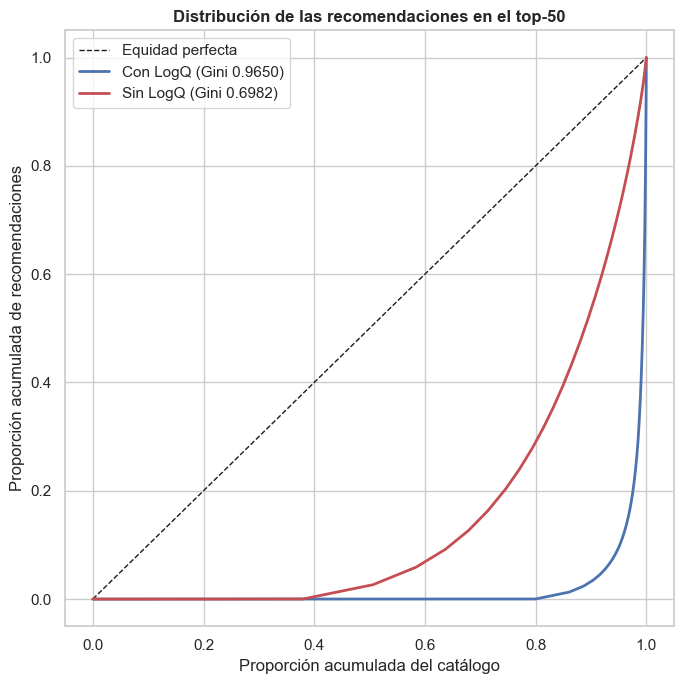

In [8]:
def lorenz(frecuencia, etiqueta, estilo):
    f = np.sort(frecuencia)
    acumulado = np.cumsum(f) / np.sum(f)
    plt.plot(np.linspace(0, 1, len(f)), acumulado, estilo, linewidth=2, label=etiqueta)

plt.figure(figsize=(7, 7))
x = np.linspace(0, 1, 100)
plt.plot(x, x, "k--", linewidth=1, label="Equidad perfecta")
lorenz(frec_logq, f"Con LogQ (Gini {res_logq['gini']:.4f})", "b-")
lorenz(frec_base, f"Sin LogQ (Gini {res_base['gini']:.4f})", "r-")
plt.title("Distribución de las recomendaciones en el top-50", fontweight="bold")
plt.xlabel("Proporción acumulada del catálogo")
plt.ylabel("Proporción acumulada de recomendaciones")
plt.legend(loc="upper left"); plt.tight_layout()
plt.savefig("experimentos/fig_lorenz_logq.png", dpi=200)
plt.show()

## Conclusión

Con presupuesto de entrenamiento y configuración idénticos, la diferencia entre ambas
variantes es atribuible únicamente a la corrección LogQ. Los valores de cobertura y de
Gini deben leerse junto con el Recall: una mayor cobertura solo representa un
descubrimiento útil del catálogo si el modelo mantiene su capacidad de recuperar los
productos efectivamente co-comprados.